In [3]:
import os
import random
from pathlib import Path

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from roboflow import Roboflow
from transformers import AutoImageProcessor, AutoModelForObjectDetection
from ultralytics import YOLO

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla V100-SXM2-32GB


## Конфигурация

Поле `backend`:
- `'yolo'` — локальный `.pt` файл, совместимый с ultralytics (YOLOv8+), поле `path`
- `'yolov5'` — локальный `.pt` файл, обученный через github.com/ultralytics/yolov5, поле `path`
- `'hf_yolo'` — `.pt` (YOLOv8+) с HuggingFace Hub через ultralytics, поля `hf_repo` + `hf_filename`
- `'hf_yolov5'` — `.pt` (YOLOv5) с HuggingFace Hub через torch.hub, поля `hf_repo` + `hf_filename`
- `'hf_detector'` — transformers `AutoModelForObjectDetection`, поле `hf_repo`
- `'roboflow_download'` — скачивает веса с Roboflow Universe и грузит как YOLO или YOLOv5
  в зависимости от `rf_export_format`.
  (поля `rf_workspace`, `rf_project`, `rf_version`, `rf_export_format`, `rf_api_key`)
  Работает только если автор модели открыл экспорт весов.
  Веса скачиваются один раз в `opensource_models/roboflow/<project>-<version>/`.

Поля `smoking_class_ids` и `smoking_class_names` заполняются **после** ячейки разведки классов.
До разведки оставьте оба поля `None`.

In [26]:
SMALL_DATASET_DIR = Path('yolo_dataset_small')
MICRO_DATASET_DIR = Path('yolo_dataset')

ROBOFLOW_API_KEY = 'tXEuWeW8Sm1SQV0EjeqY'  # можно задать один раз здесь
RF_DOWNLOAD_DIR = Path('opensource_models/roboflow')
RF_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

OWN_MODELS = [
    {
        'name': 'YOLOv26l_small',
        'backend': 'yolo',
        'path': 'runs/detect/runs/detect/smoking_yolo26l/weights/best.pt',
        'smoking_class_ids': [0],
        'smoking_class_names': None,
    },
    {
        'name': 'YOLOv26m_micro',
        'backend': 'yolo',
        'path': 'runs/detect/small_boxes/smoking_yolo26l/weights/best.pt',
        'smoking_class_ids': [0],
        'smoking_class_names': None,
    },
]

OPENSOURCE_MODELS = [
    # локальный YOLOv5 .pt
    {
        'name': '/AarnoStormborn_yolo',
        'backend': 'yolov5',
        'path': 'opensource_models/AarnoStormborn_yolo_weights.pt',
        'smoking_class_ids': None,
        'smoking_class_names': None,
    },
    # YOLO .pt с HuggingFace Hub
    {
        'name': 'hf_yolo_smoking',
        'backend': 'hf_yolo',
        'hf_repo': 'Enos-123/smoking-detection',
        'hf_filename': 'best.pt',
        'smoking_class_ids': None,
        'smoking_class_names': None,
    },
    # transformers-детектор с HuggingFace Hub
    # модель с Roboflow Universe — скачивает веса локально
    # rf_export_format: 'yolov8' (рекомендуется), 'yolov5', 'yolov9' и др.
    # если экспорт весов недоступен — Roboflow выбросит ошибку
    {
        'name': 'smoking-1nw3o',
        'backend': 'roboflow_download',
        'rf_workspace': 'smoking-1nw3o',
        'rf_project': 'smoking-ppkpw',
        'rf_version': 1,
        'rf_export_format': 'yolov8',
        'rf_api_key': ROBOFLOW_API_KEY,
        'smoking_class_ids': None,
        'smoking_class_names': None,
    },
    {
        'name': 'videocontentmoderator',
        'backend': 'roboflow_download',
        'rf_workspace': 'videocontentmoderator',
        'rf_project': 'video_content_moderator',
        'rf_version': 1,
        'rf_export_format': 'yolov8',
        'rf_api_key': ROBOFLOW_API_KEY,
        'smoking_class_ids': None,
        'smoking_class_names': None,
    },
    {
        'name': 'kyunghee-university-ada5d',
        'backend': 'roboflow_download',
        'rf_workspace': 'kyunghee-university-ada5d',
        'rf_project': 'smoking-detection-3gefl',
        'rf_version': 4,
        'rf_export_format': 'yolov8',
        'rf_api_key': ROBOFLOW_API_KEY,
        'smoking_class_ids': None,
        'smoking_class_names': None,
    },
]

CONF_THRESHOLD = 0.3
N_VISUAL_SAMPLES = 5
OUTPUT_DIR = Path('comparison_results')
OUTPUT_DIR.mkdir(exist_ok=True)

## Обёртки над моделями

In [27]:
class YoloWrapper:
    def __init__(self, model):
        self.model = model

    @property
    def names(self):
        return self.model.names

    def predict_all(self, img_path, conf):
        pred_results = self.model.predict(str(img_path), conf=conf, device=device, verbose=False)
        if len(pred_results) == 0 or pred_results[0].boxes is None:
            return [], [], []
        boxes_obj = pred_results[0].boxes
        boxes = boxes_obj.xyxy.cpu().numpy()
        scores = boxes_obj.conf.cpu().numpy()
        class_ids = boxes_obj.cls.cpu().numpy().astype(int)
        return list(boxes), list(scores.astype(float)), list(class_ids)

    def predict_boxes(self, img_path, conf, smoking_class_ids):
        boxes, scores, class_ids = self.predict_all(img_path, conf)
        filtered = [
            (boxes[i], scores[i])
            for i in range(len(class_ids))
            if class_ids[i] in smoking_class_ids
        ]
        if not filtered:
            return [], []
        fboxes, fscores = zip(*filtered)
        return list(fboxes), list(fscores)


class YoloV5Wrapper:
    # грузит модели, обученные через github.com/ultralytics/yolov5
    def __init__(self, model):
        self.model = model
        self.model.conf = 0.01

    @property
    def names(self):
        names_raw = self.model.names
        if isinstance(names_raw, dict):
            return {int(k): v for k, v in names_raw.items()}
        return {i: n for i, n in enumerate(names_raw)}

    def predict_all(self, img_path, conf):
        self.model.conf = conf
        results = self.model(str(img_path))
        preds = results.xyxy[0].cpu().numpy()
        if len(preds) == 0:
            return [], [], []
        boxes = [preds[i, :4] for i in range(len(preds))]
        scores = [float(preds[i, 4]) for i in range(len(preds))]
        class_ids = [int(preds[i, 5]) for i in range(len(preds))]
        return boxes, scores, class_ids

    def predict_boxes(self, img_path, conf, smoking_class_ids):
        boxes, scores, class_ids = self.predict_all(img_path, conf)
        filtered = [
            (boxes[i], scores[i])
            for i in range(len(class_ids))
            if class_ids[i] in smoking_class_ids
        ]
        if not filtered:
            return [], []
        fboxes, fscores = zip(*filtered)
        return list(fboxes), list(fscores)


class HFDetectorWrapper:
    def __init__(self, processor, model, hf_device):
        self.processor = processor
        self.model = model
        self.hf_device = hf_device

    @property
    def names(self):
        id2label = self.model.config.id2label
        return {int(k): v for k, v in id2label.items()}

    def _run_inference(self, img_path, conf):
        img_pil = Image.open(str(img_path)).convert('RGB')
        orig_w, orig_h = img_pil.size
        inputs = self.processor(images=img_pil, return_tensors='pt')
        inputs = {k: v.to(self.hf_device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = self.model(**inputs)
        target_sizes = torch.tensor([[orig_h, orig_w]])
        results = self.processor.post_process_object_detection(
            outputs, threshold=conf, target_sizes=target_sizes
        )[0]
        boxes = results['boxes'].cpu().numpy()
        scores = results['scores'].cpu().numpy()
        class_ids = results['labels'].cpu().numpy().astype(int)
        return list(boxes), list(scores.astype(float)), list(class_ids)

    def predict_all(self, img_path, conf):
        return self._run_inference(img_path, conf)

    def predict_boxes(self, img_path, conf, smoking_class_ids):
        boxes, scores, class_ids = self._run_inference(img_path, conf)
        filtered = [
            (boxes[i], scores[i])
            for i in range(len(class_ids))
            if class_ids[i] in smoking_class_ids
        ]
        if not filtered:
            return [], []
        fboxes, fscores = zip(*filtered)
        return list(fboxes), list(fscores)

## Загрузка моделей

In [28]:
def _load_yolov5_local(path):
    return torch.hub.load(
        'ultralytics/yolov5',
        'custom',
        path=str(path),
        force_reload=False,
        verbose=False,
    )


def _find_weights_in_dir(directory):
    directory = Path(directory)
    candidates = list(directory.rglob('best.pt'))
    if not candidates:
        candidates = list(directory.rglob('*.pt'))
    if not candidates:
        return None
    return candidates[0]


def load_model(cfg):
    backend = cfg['backend']

    if backend == 'yolo':
        path = Path(cfg['path'])
        if not path.exists():
            print(f"Model file not found, skipping: {path}")
            return None
        return YoloWrapper(YOLO(str(path)))

    if backend == 'yolov5':
        path = Path(cfg['path'])
        if not path.exists():
            print(f"Model file not found, skipping: {path}")
            return None
        return YoloV5Wrapper(_load_yolov5_local(path))

    if backend == 'hf_yolo':
        from huggingface_hub import hf_hub_download
        local_path = hf_hub_download(
            repo_id=cfg['hf_repo'],
            filename=cfg['hf_filename'],
        )
        return YoloWrapper(YOLO(local_path))

    if backend == 'hf_yolov5':
        from huggingface_hub import hf_hub_download
        local_path = hf_hub_download(
            repo_id=cfg['hf_repo'],
            filename=cfg['hf_filename'],
        )
        return YoloV5Wrapper(_load_yolov5_local(local_path))

    if backend == 'hf_detector':
        processor = AutoImageProcessor.from_pretrained(cfg['hf_repo'])
        model = AutoModelForObjectDetection.from_pretrained(cfg['hf_repo'])
        model = model.to(device)
        model.eval()
        return HFDetectorWrapper(processor, model, device)

    if backend == 'roboflow_download':
        api_key = cfg.get('rf_api_key') or ROBOFLOW_API_KEY
        if not api_key:
            print(f"Roboflow API key not set for model {cfg['name']}, skipping")
            return None

        project_name = cfg['rf_project']
        version_num = cfg['rf_version']
        export_format = cfg.get('rf_export_format', 'yolov8')
        local_dir = RF_DOWNLOAD_DIR / f"{project_name}-{version_num}"

        weights_path = _find_weights_in_dir(local_dir) if local_dir.exists() else None

        if weights_path is None:
            print(f"Downloading {cfg['name']} from Roboflow ({export_format})...")
            local_dir.mkdir(parents=True, exist_ok=True)
            rf = Roboflow(api_key=api_key)
            project = rf.workspace(cfg['rf_workspace']).project(project_name)
            version = project.version(version_num)
            version.download(export_format, location=str(local_dir))
            weights_path = _find_weights_in_dir(local_dir)

        if weights_path is None:
            print(f"Weights not found after download in {local_dir}, skipping")
            return None

        print(f"Loading weights from {weights_path}")
        is_v5_format = export_format.startswith('yolov5')
        if is_v5_format:
            return YoloV5Wrapper(_load_yolov5_local(weights_path))
        return YoloWrapper(YOLO(str(weights_path)))

    print(f"Unknown backend '{backend}' for model {cfg['name']}, skipping")
    return None


def resolve_smoking_class_ids(wrapper, smoking_class_ids, smoking_class_names):
    if smoking_class_ids is not None:
        return smoking_class_ids
    if smoking_class_names is None:
        return []
    names = wrapper.names
    ids = []
    for idx, name in names.items():
        for target_name in smoking_class_names:
            if target_name.lower() in name.lower():
                ids.append(idx)
                break
    print(f"Resolved smoking class ids: {ids} from model names: {names}")
    return ids

## Разведка классов

Для каждой модели выводятся все классы и сырые предсказания на нескольких случайных изображениях.
После просмотра заполните `smoking_class_ids` или `smoking_class_names` в конфигурации выше и перезапустите ноутбук с ячейки конфигурации.

In [29]:
def pick_probe_images(dataset_dir, split='val', n=3):
    images_dir = dataset_dir / split / 'images'
    if not images_dir.exists():
        images_dir = dataset_dir / 'test' / 'images'
    if not images_dir.exists():
        return []
    paths = [
        p for p in images_dir.iterdir()
        if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    ]
    return random.sample(paths, min(n, len(paths)))


def inspect_model_classes(cfg, probe_images, conf=0.1):
    print(f"\n{'='*60}")
    print(f"Model: {cfg['name']}  (backend={cfg['backend']})")

    wrapper = load_model(cfg)
    if wrapper is None:
        return

    if not probe_images:
        print("No probe images available")
        return

    names_str = ', '.join(f'{k}:{v}' for k, v in sorted(wrapper.names.items())) or 'n/a'
    print(f"Classes: {names_str}")

    n_cols = len(probe_images)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6))
    if n_cols == 1:
        axes = [axes]

    for ax, img_path in zip(axes, probe_images):
        img_cv = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

        boxes, scores, class_ids = wrapper.predict_all(img_path, conf=conf)

        ax.imshow(img_rgb)
        for box, score, cls_id in zip(boxes, scores, class_ids):
            x1, y1, x2, y2 = box
            cls_name = wrapper.names.get(cls_id, str(cls_id))
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor='orange', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                x1, max(y1 - 5, 0),
                f'{cls_id}:{cls_name} {score:.2f}',
                color='orange', fontsize=8, weight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.6)
            )

        ax.set_title(f'{img_path.name}\nTotal preds: {len(boxes)}', fontsize=8)
        ax.axis('off')

    fig.suptitle(
        f'Разведка: {cfg["name"]} | conf>{conf} | все классы\n{names_str}',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'inspect_{cfg["name"]}.png', dpi=120, bbox_inches='tight')
    plt.show()


Model: YOLOv26l_small  (backend=yolo)
Classes: 0:smoking


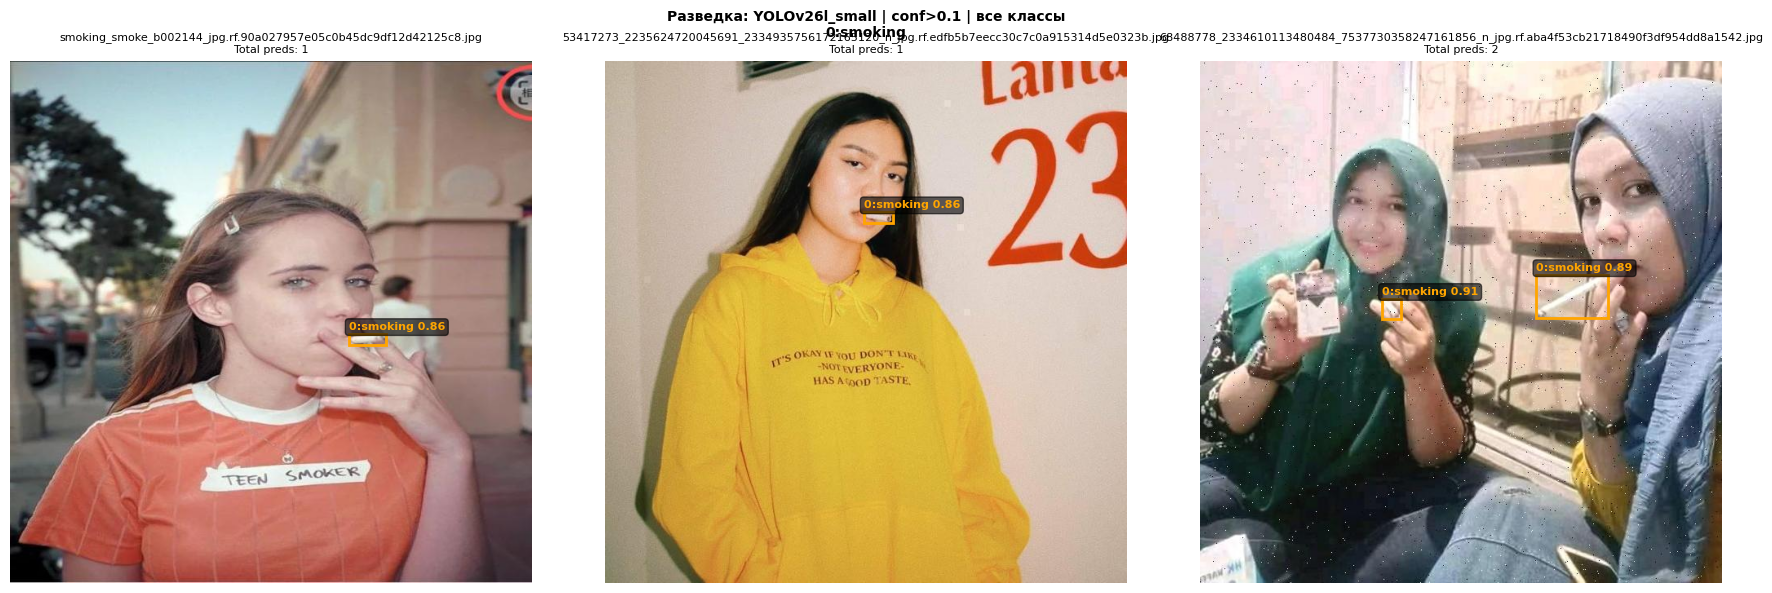


Model: YOLOv26m_micro  (backend=yolo)
Classes: 0:smoking


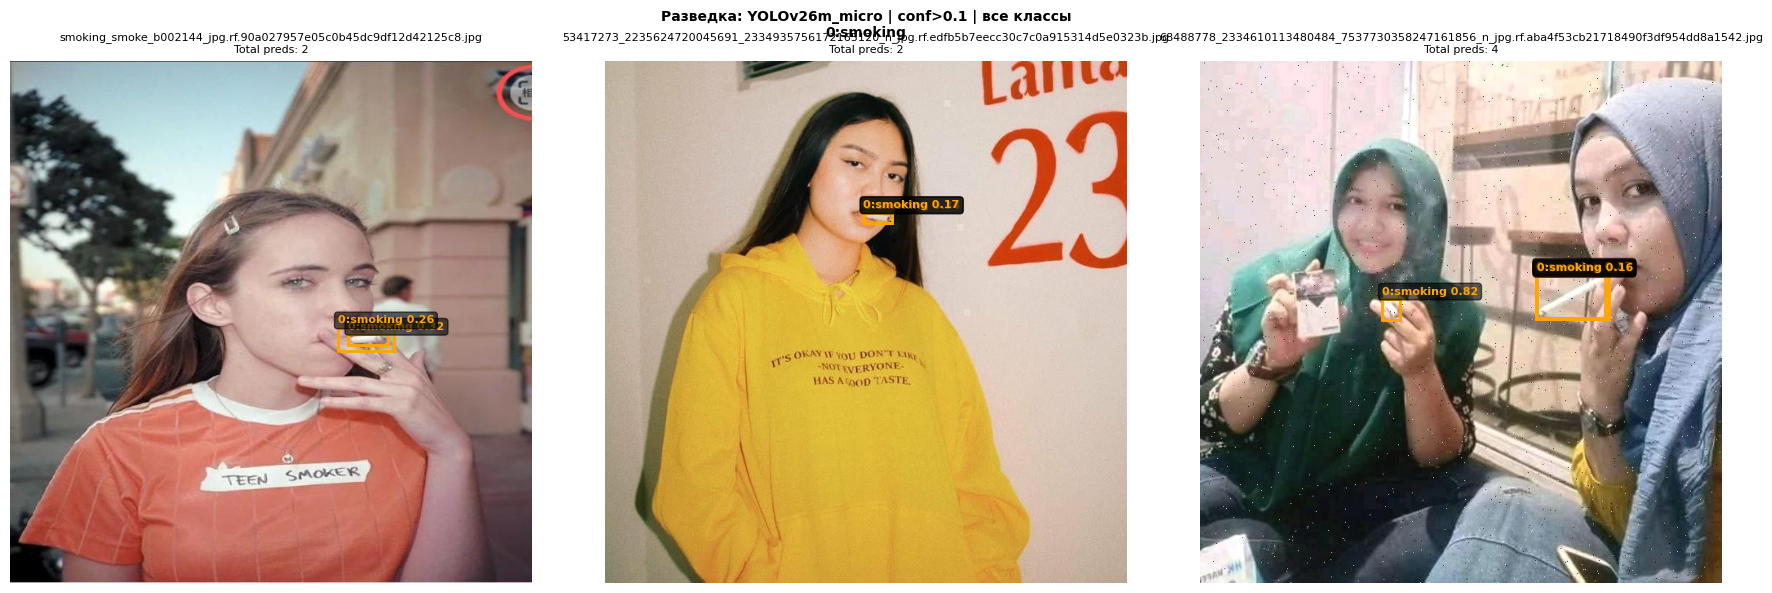


Model: /AarnoStormborn_yolo  (backend=yolo)


TypeError: ERROR ❌️ opensource_models/AarnoStormborn_yolo_weights.pt appears to be an Ultralytics YOLOv5 model originally trained with https://github.com/ultralytics/yolov5.
This model is NOT forwards compatible with YOLOv8 at https://github.com/ultralytics/ultralytics.
Recommend fixes are to train a new model using the latest 'ultralytics' package or to run a command with an official Ultralytics model, i.e. 'yolo predict model=yolo26n.pt'

In [30]:
probe_dataset_dir = SMALL_DATASET_DIR if SMALL_DATASET_DIR.exists() else MICRO_DATASET_DIR
probe_images = pick_probe_images(probe_dataset_dir, split='val', n=3)

for cfg in OWN_MODELS + OPENSOURCE_MODELS:
    inspect_model_classes(cfg, probe_images, conf=0.1)

---
**После просмотра разведки:** вернитесь в ячейку конфигурации и заполните `smoking_class_ids` или `smoking_class_names` для каждой модели, затем выполните оставшиеся ячейки.

---

## Метрики

In [ ]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    if union <= 0:
        return 0.0
    return inter / union


def compute_ap(recalls, precisions):
    recalls = np.concatenate(([0.0], recalls, [1.0]))
    precisions = np.concatenate(([0.0], precisions, [0.0]))
    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i + 1])
    indices = np.where(recalls[1:] != recalls[:-1])[0] + 1
    ap = np.sum((recalls[indices] - recalls[indices - 1]) * precisions[indices])
    return float(ap)


def evaluate_wrapper_on_split(
    wrapper,
    smoking_class_ids,
    images_dir,
    labels_dir,
    conf=0.3,
    iou_threshold=0.5,
):
    image_paths = [
        p for p in images_dir.iterdir()
        if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    ]

    all_scores = []
    all_tp = []
    n_gt_total = 0

    for img_path in image_paths:
        label_path = labels_dir / (img_path.stem + '.txt')

        gt_boxes = []
        if label_path.exists():
            img_cv = cv2.imread(str(img_path))
            if img_cv is None:
                continue
            h, w = img_cv.shape[:2]
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cx, cy, bw, bh = map(float, parts[1:5])
                    x1 = (cx - bw / 2) * w
                    y1 = (cy - bh / 2) * h
                    x2 = (cx + bw / 2) * w
                    y2 = (cy + bh / 2) * h
                    gt_boxes.append([x1, y1, x2, y2])

        n_gt_total += len(gt_boxes)
        matched_gt = set()

        pred_boxes, pred_scores = wrapper.predict_boxes(img_path, conf, smoking_class_ids)

        if len(pred_scores) == 0:
            continue

        order = np.argsort(-np.array(pred_scores))
        pred_boxes = [pred_boxes[i] for i in order]
        pred_scores = [pred_scores[i] for i in order]

        for pb, sc in zip(pred_boxes, pred_scores):
            best_iou = 0.0
            best_gt_idx = -1
            for gi, gb in enumerate(gt_boxes):
                if gi in matched_gt:
                    continue
                iou = compute_iou(pb, gb)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gi
            if best_iou >= iou_threshold and best_gt_idx >= 0:
                all_tp.append(1)
                matched_gt.add(best_gt_idx)
            else:
                all_tp.append(0)
            all_scores.append(sc)

    if len(all_scores) == 0 or n_gt_total == 0:
        return {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'mAP50': 0.0, 'n_gt': n_gt_total, 'n_pred': 0}

    order = np.argsort(-np.array(all_scores))
    tp_sorted = np.array(all_tp)[order]
    cum_tp = np.cumsum(tp_sorted)
    cum_fp = np.cumsum(1 - tp_sorted)

    precisions = cum_tp / (cum_tp + cum_fp + 1e-9)
    recalls = cum_tp / (n_gt_total + 1e-9)

    ap = compute_ap(recalls, precisions)
    final_precision = float(precisions[-1])
    final_recall = float(recalls[-1])
    f1 = 2 * final_precision * final_recall / (final_precision + final_recall + 1e-9)

    return {
        'precision': final_precision,
        'recall': final_recall,
        'f1': float(f1),
        'mAP50': ap,
        'n_gt': n_gt_total,
        'n_pred': len(all_scores),
    }


def evaluate_cfg_on_dataset(model_cfg, dataset_dir, dataset_label, conf=0.3):
    print(f"Loading model: {model_cfg['name']} (backend={model_cfg['backend']})")
    wrapper = load_model(model_cfg)
    if wrapper is None:
        return []

    smoking_class_ids = resolve_smoking_class_ids(
        wrapper, model_cfg['smoking_class_ids'], model_cfg['smoking_class_names']
    )
    if len(smoking_class_ids) == 0:
        print(f"WARNING: no smoking class ids resolved for model {model_cfg['name']} — skipping evaluation")
        return []

    rows = []
    for split in ['val', 'test']:
        images_dir = dataset_dir / split / 'images'
        labels_dir = dataset_dir / split / 'labels'
        if not images_dir.exists():
            print(f"Split '{split}' not found in {dataset_dir}, skipping")
            continue

        print(f"  Evaluating on {dataset_label}/{split}...")
        metrics = evaluate_wrapper_on_split(
            wrapper, smoking_class_ids, images_dir, labels_dir, conf=conf
        )
        print(
            f"    mAP50={metrics['mAP50']:.4f}  P={metrics['precision']:.4f}"
            f"  R={metrics['recall']:.4f}  F1={metrics['f1']:.4f}"
            f"  GT={metrics['n_gt']}  Pred={metrics['n_pred']}"
        )
        rows.append({
            'model': model_cfg['name'],
            'backend': model_cfg['backend'],
            'dataset': dataset_label,
            'split': split,
            'mAP50': metrics['mAP50'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1': metrics['f1'],
            'n_gt': metrics['n_gt'],
            'n_pred': metrics['n_pred'],
        })
    return rows

## Оценка метрик

In [ ]:
all_metrics_rows = []

for model_cfg in OWN_MODELS + OPENSOURCE_MODELS:
    print(f"\n{'='*60}")
    print(f"Model: {model_cfg['name']}")

    for dataset_dir, dataset_label in [
        (SMALL_DATASET_DIR, 'small'),
        (MICRO_DATASET_DIR, 'micro'),
    ]:
        if not dataset_dir.exists():
            print(f"Dataset dir not found: {dataset_dir}")
            continue
        rows = evaluate_cfg_on_dataset(model_cfg, dataset_dir, dataset_label, conf=CONF_THRESHOLD)
        all_metrics_rows.extend(rows)

metrics_df = pd.DataFrame(all_metrics_rows)
metrics_df.to_csv(OUTPUT_DIR / 'comparison_metrics.csv', index=False)
print(f"\nMetrics saved to {OUTPUT_DIR / 'comparison_metrics.csv'}")
metrics_df

## Сводная таблица по сплитам

In [ ]:
for split in ['val', 'test']:
    subset = metrics_df[metrics_df['split'] == split]
    if subset.empty:
        continue
    print(f"\n{'='*60}")
    print(f"Split: {split}")
    print(
        subset[['model', 'backend', 'dataset', 'mAP50', 'precision', 'recall', 'f1']]
        .sort_values(['dataset', 'mAP50'], ascending=[True, False])
        .to_string(index=False)
    )

## Визуализация метрик

In [ ]:
for split in ['val', 'test']:
    subset = metrics_df[metrics_df['split'] == split]
    if subset.empty:
        continue

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    fig.suptitle(f'Сравнение моделей | split={split}', fontsize=14, fontweight='bold')

    for ax, metric in zip(axes, ['mAP50', 'precision', 'recall', 'f1']):
        pivot = subset.pivot(index='model', columns='dataset', values=metric)
        pivot.plot(kind='bar', ax=ax, width=0.7)
        ax.set_title(metric.upper(), fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
        ax.legend(title='dataset', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'metrics_comparison_{split}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Визуальный инференс (только smoking-классы)

In [ ]:
def visual_inference_comparison(
    models_cfgs,
    images_dir,
    labels_dir,
    dataset_label,
    split,
    n_samples=5,
    conf=0.3,
    out_dir=None,
):
    image_paths = [
        p for p in images_dir.iterdir()
        if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    ]
    if len(image_paths) == 0:
        print(f"No images in {images_dir}")
        return
    sample_paths = random.sample(image_paths, min(n_samples, len(image_paths)))

    loaded = []
    for cfg in models_cfgs:
        wrapper = load_model(cfg)
        if wrapper is None:
            continue
        ids = resolve_smoking_class_ids(
            wrapper, cfg['smoking_class_ids'], cfg['smoking_class_names']
        )
        if len(ids) == 0:
            print(f"Skipping visual inference for {cfg['name']}: no smoking class ids")
            continue
        loaded.append((cfg['name'], wrapper, ids))

    if not loaded:
        print("No models loaded for visual inference")
        return

    n_cols = len(sample_paths)
    n_rows = len(loaded) + 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for col_idx, img_path in enumerate(sample_paths):
        img_cv = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]

        ax_gt = axes[0, col_idx]
        ax_gt.imshow(img_rgb)

        label_path = labels_dir / (img_path.stem + '.txt')
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cx, cy, bw, bh = map(float, parts[1:5])
                    x_min = int((cx - bw / 2) * w)
                    y_min = int((cy - bh / 2) * h)
                    rect = patches.Rectangle(
                        (x_min, y_min), int(bw * w), int(bh * h),
                        linewidth=2, edgecolor='green', facecolor='none'
                    )
                    ax_gt.add_patch(rect)

        ax_gt.set_title(f'Ground Truth\n{img_path.name}', fontsize=8)
        ax_gt.axis('off')

        for row_idx, (model_name, wrapper, smoking_class_ids) in enumerate(loaded):
            ax = axes[row_idx + 1, col_idx]
            ax.imshow(img_rgb)

            pred_boxes, pred_scores = wrapper.predict_boxes(img_path, conf, smoking_class_ids)

            for box, score in zip(pred_boxes, pred_scores):
                x1, y1, x2, y2 = box
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
                )
                ax.add_patch(rect)
                ax.text(
                    x1, y1 - 5, f'{score:.2f}',
                    color='red', fontsize=9, weight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
                )

            ax.set_title(f'{model_name}\nPred: {len(pred_boxes)}', fontsize=8)
            ax.axis('off')

    green_patch = patches.Patch(color='green', label='Ground Truth')
    red_patch = patches.Patch(color='red', label=f'Prediction (conf>{conf})')
    fig.legend(handles=[green_patch, red_patch], loc='upper center', ncol=2, fontsize=11)
    fig.suptitle(
        f'Визуальный инференс | dataset={dataset_label} | split={split}',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()

    if out_dir is not None:
        save_path = out_dir / f'visual_inference_{dataset_label}_{split}.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

In [ ]:
all_model_cfgs = OWN_MODELS + OPENSOURCE_MODELS

for dataset_dir, dataset_label in [
    (SMALL_DATASET_DIR, 'small'),
    (MICRO_DATASET_DIR, 'micro'),
]:
    if not dataset_dir.exists():
        print(f"Dataset dir not found: {dataset_dir}")
        continue

    for split in ['val', 'test']:
        images_dir = dataset_dir / split / 'images'
        labels_dir = dataset_dir / split / 'labels'
        if not images_dir.exists():
            continue

        print(f"\n{'='*60}")
        print(f"Visual inference: dataset={dataset_label}, split={split}")
        visual_inference_comparison(
            all_model_cfgs,
            images_dir,
            labels_dir,
            dataset_label,
            split,
            n_samples=N_VISUAL_SAMPLES,
            conf=CONF_THRESHOLD,
            out_dir=OUTPUT_DIR,
        )

## Итоговая сводка

In [ ]:
summary = (
    metrics_df
    .groupby(['model', 'backend', 'dataset', 'split'])[['mAP50', 'precision', 'recall', 'f1']]
    .mean()
    .round(4)
    .reset_index()
    .sort_values(['dataset', 'split', 'mAP50'], ascending=[True, True, False])
)
print(summary.to_string(index=False))
summary.to_csv(OUTPUT_DIR / 'comparison_summary.csv', index=False)